**Theoretical Questions:**

In [ ]:
'''1.What is unsupervised learning in the context of machine learning?
Unsupervised learning is a type of machine learning where the model works on unlabeled data (no target/output).
It tries to find patterns, groups, or structures in the data.
 Example: Grouping customers based on buying behavior.

In [ ]:
'''2.How does K-Means clustering algorithm work?
K-Means groups data into K clusters:
Choose number of clusters (K)
Initialize K centroids randomly
Assign each point to nearest centroid
Recalculate centroids (mean of points)
Repeat steps 3–4 until stable

In [ ]:
'''3.Explain the concept of a dendrogram in hierarchical clustering?
A dendrogram is a tree-like diagram used in hierarchical clustering.
Shows how clusters are merged or split
Height represents distance between clusters
Helps decide number of clusters

In [ ]:
'''4.What is the main difference between K-Means and Hierarchical Clustering?
 Feature     | K-Means         | Hierarchical
 ----------- | --------------- | ---------------------
 Type        | Partition-based | Tree-based
 K required? | Yes             | No (can decide later)
 Speed       | Fast            | Slower
 Output      | Fixed clusters  | Dendrogram

In [ ]:
'''5.What are the advantages of DBSCAN over K-Means?
Detects arbitrary shaped clusters
Handles noise/outliers
No need to specify number of clusters (K)

In [ ]:
'''6.When would you use Silhouette Score in clustering?
Evaluate clustering quality
Compare different cluster numbers
Works when true labels are not available

In [ ]:
'''7.What are the limitations of Hierarchical Clustering?
Computationally expensive (slow for large data)
Hard to undo merges/splits
Sensitive to noise and outliers

In [ ]:
'''8.Why is feature scaling important in clustering algorithms like K-Means?
K-Means uses distance (usually Euclidean)
Without scaling:
Features with larger values dominate
Clusters become biased

In [ ]:
'''9.How does DBSCAN identify noise points?
Points are labeled as noise if:
They have fewer neighbors than MinPts
Within a radius ε (epsilon)

In [ ]:
'''10.Define inertia in the context of K-Means?
nertia = Sum of squared distances of points from their cluster centroid
Lower inertia = better clustering (but not always perfect)

In [ ]:
'''11.What is the elbow method in K-Means clustering?
Used to find optimal K:
Plot K vs Inertia
Look for a point where decrease slows down (elbow point)

In [ ]:
'''12.Describe the concept of "density" in DBSCAN?
Density = number of points in a region
 High density → cluster
 Low density → noise

In [ ]:
'''13.Can hierarchical clustering be used on categorical data?
Yes
But you need:
Proper distance measure (e.g., Hamming distance)

In [ ]:
'''14.What does a negative Silhouette Score indicate?
Data point is closer to another cluster than its own
 Poor clustering / misclassification

In [ ]:
'''15.Explain the term "linkage criteria" in hierarchical clustering?
It defines how distance between clusters is calculated:
Single linkage → closest points
Complete linkage → farthest points
Average linkage → average distance

In [ ]:
'''16.Why might K-Means clustering perform poorly on data with varying cluster sizes or densities?
Because:
Assumes equal-sized, spherical clusters
Struggles with:
Different densities
Uneven cluster sizes
Non-circular shapes

In [ ]:
'''17.What are the core parameters in DBSCAN, and how do they influence clustering?
Core Parameters of DBSCAN
ε (epsilon) → neighborhood radius
MinPts → minimum points to form cluster
Effects:
Large ε → fewer clusters
Small ε → more noise

In [ ]:
'''18.How does K-Means++ improve upon standard K-Means initialization?
Chooses better initial centroids
Spread out points intelligently
Reduces chances of poor clustering

In [ ]:
'''19.What is agglomerative clustering?
A type of hierarchical clustering:
 Start with each point as its own cluster
 Merge closest clusters step by step

In [ ]:
'''20.What makes Silhouette Score a better metric than just inertia for model evaluation?
Inertia only measures compactness
Silhouette considers:
Cohesion (within cluster)
Separation (between clusters)
So it gives a more complete evaluation

**Practical** **Questions**:

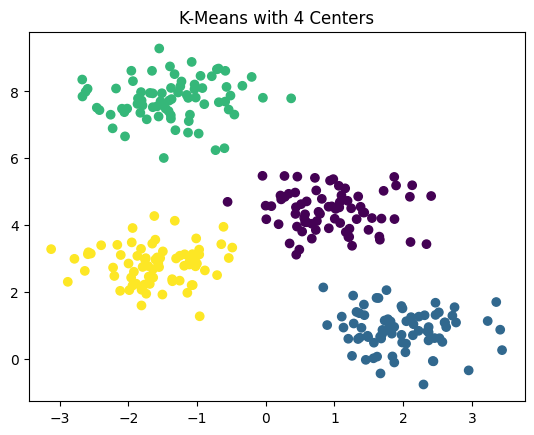

In [2]:
# 21. Generate synthetic data with 4 centers using make_blobs and apply K-Means clustering. Visualize using a scatter plot.
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X, y = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)
kmeans = KMeans(n_clusters=4, random_state=0, n_init=10)
kmeans.fit(X)

plt.scatter(X[:, 0], X[:, 1], c=kmeans.labels_, cmap='viridis')
plt.title("K-Means with 4 Centers")
plt.show()

In [3]:
#22. Load the Iris dataset and use Agglomerative Clustering to group the data into 3 clusters. Display the first 10 predicted labels.
from sklearn.datasets import load_iris
from sklearn.cluster import AgglomerativeClustering

iris = load_iris()
agg_clustering = AgglomerativeClustering(n_clusters=3)
labels = agg_clustering.fit_predict(iris.data)
print(f"First 10 labels: {labels[:10]}")

First 10 labels: [1 1 1 1 1 1 1 1 1 1]


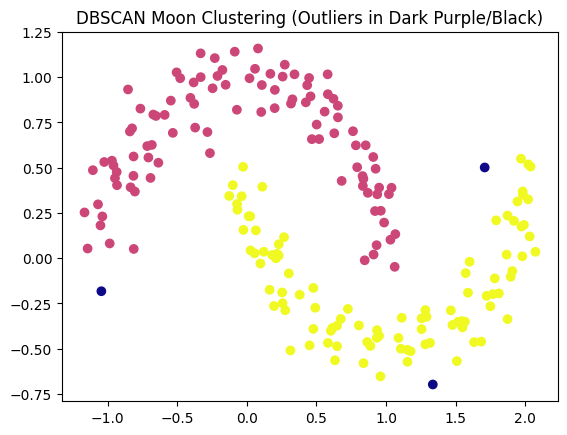

In [4]:
#23. Generate synthetic data using make_moons and apply DBSCAN. Highlight outliers in the plot.
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN

X, _ = make_moons(n_samples=200, noise=0.1, random_state=0)
dbscan = DBSCAN(eps=0.2, min_samples=5)
labels = dbscan.fit_predict(X)

# Outliers are labeled as -1 in DBSCAN
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='plasma')
plt.title("DBSCAN Moon Clustering (Outliers in Dark Purple/Black)")
plt.show()

In [5]:
#24. Load the Wine dataset and apply K-Means clustering after standardizing the features. Print the size of each cluster.
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
import pandas as pd

wine = load_wine()
X_scaled = StandardScaler().fit_transform(wine.data)
kmeans = KMeans(n_clusters=3, random_state=42).fit(X_scaled)

print(pd.Series(kmeans.labels_).value_counts())

0    65
2    62
1    51
Name: count, dtype: int64


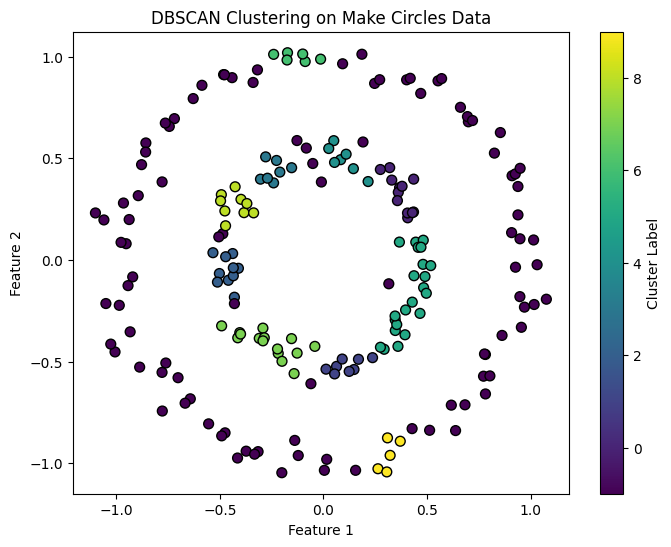

In [10]:
#25. Use make_circles to generate synthetic data and cluster it using DBSCAN. Plot the result.
from sklearn.datasets import make_circles
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

# Generate synthetic circular data
X, y = make_circles(n_samples=200, noise=0.05, factor=0.5, random_state=0)

# Apply DBSCAN clustering
dbscan = DBSCAN(eps=0.1, min_samples=5)
labels = dbscan.fit_predict(X)

# Plot the result
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=50, edgecolors='k')
plt.title("DBSCAN Clustering on Make Circles Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.colorbar(label='Cluster Label')
plt.show()

In [11]:
#26. Load the Breast Cancer dataset, apply MinMaxScaler, and use K-Means with 2 clusters. Output the cluster centroids
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import MinMaxScaler

data = load_breast_cancer()
X_scaled = MinMaxScaler().fit_transform(data.data)
kmeans = KMeans(n_clusters=2).fit(X_scaled)
print("Cluster Centroids:\n", kmeans.cluster_centers_)

Cluster Centroids:
 [[0.25535358 0.28833455 0.24696416 0.14388369 0.35743076 0.18019471
  0.10344776 0.1306603  0.34011829 0.25591606 0.06427485 0.18843043
  0.05975663 0.02870108 0.18158628 0.13242941 0.05821528 0.18069336
  0.17221057 0.08403996 0.2052406  0.32069002 0.19242138 0.09943446
  0.3571115  0.14873935 0.13142287 0.26231363 0.22639412 0.15437354]
 [0.50483563 0.39560329 0.50578661 0.36376576 0.46988732 0.42226302
  0.41838662 0.46928035 0.45899738 0.29945886 0.19093085 0.19112073
  0.17903433 0.13086432 0.18017962 0.25890126 0.12542475 0.30942779
  0.190072   0.13266975 0.48047448 0.45107371 0.4655302  0.31460597
  0.49868817 0.36391461 0.39027292 0.65827197 0.33752296 0.26041387]]


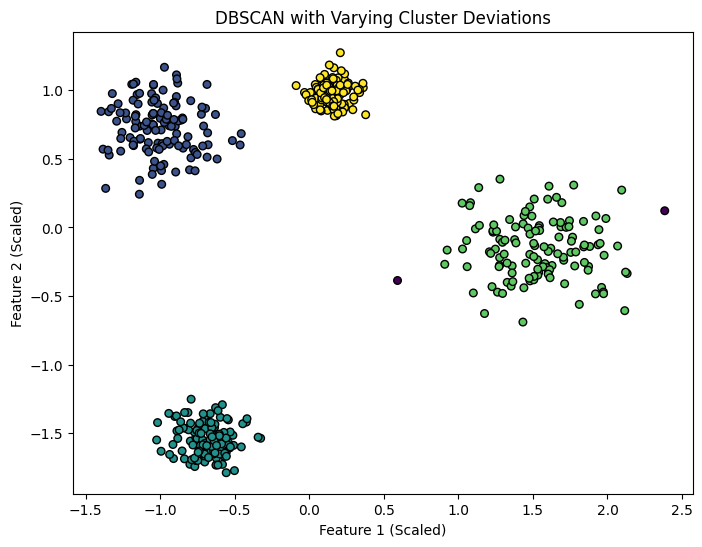

In [12]:
#27. Generate synthetic data using make_blobs with varying cluster standard deviations and cluster with DBSCAN.
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# 1. Generate synthetic data with different standard deviations (e.g., 0.5, 1.5, 0.7, 1.2)
X, y = make_blobs(n_samples=500,
                  centers=4,
                  cluster_std=[0.5, 1.5, 0.7, 1.2],
                  random_state=42)

# 2. Standardize features (DBSCAN is very sensitive to scale)
X = StandardScaler().fit_transform(X)

# 3. Apply DBSCAN
# eps is the maximum distance between two samples for one to be considered as in the neighborhood of the other.
dbscan = DBSCAN(eps=0.3, min_samples=5)
labels = dbscan.fit_predict(X)

# 4. Plot the result
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', marker='o', s=30, edgecolors='k')
plt.title("DBSCAN with Varying Cluster Deviations")
plt.xlabel("Feature 1 (Scaled)")
plt.ylabel("Feature 2 (Scaled)")
plt.show()

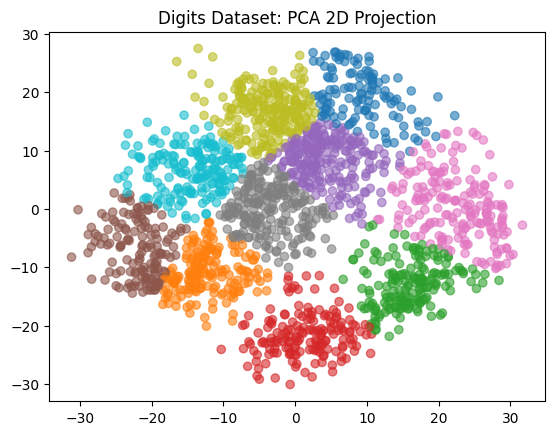

In [13]:
#28. Load the Digits dataset, reduce it to 2D using PCA, and visualize clusters from K-Means.
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA

digits = load_digits()
pca = PCA(n_components=2)
X_pca = pca.fit_transform(digits.data)

kmeans = KMeans(n_clusters=10)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans.fit_predict(X_pca), cmap='tab10', alpha=0.6)
plt.title("Digits Dataset: PCA 2D Projection")
plt.show()

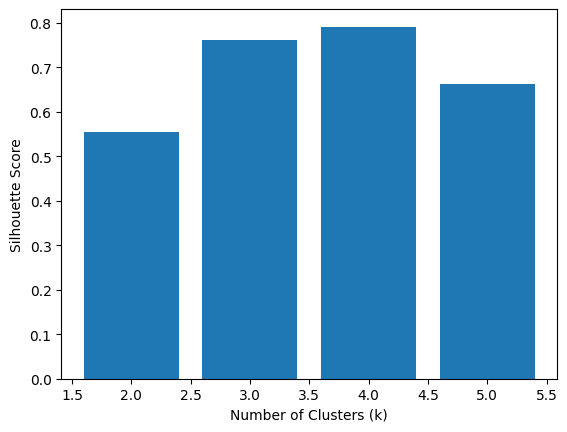

In [14]:
#29. Create synthetic data using make_blobs and evaluate silhouette scores for $k=2$ to $5$. Display as a bar chart.
from sklearn.metrics import silhouette_score

X, _ = make_blobs(n_samples=500, centers=4, random_state=42)
scores = []
ks = [2, 3, 4, 5]

for k in ks:
    labels = KMeans(n_clusters=k).fit_predict(X)
    scores.append(silhouette_score(X, labels))

plt.bar(ks, scores)
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.show()

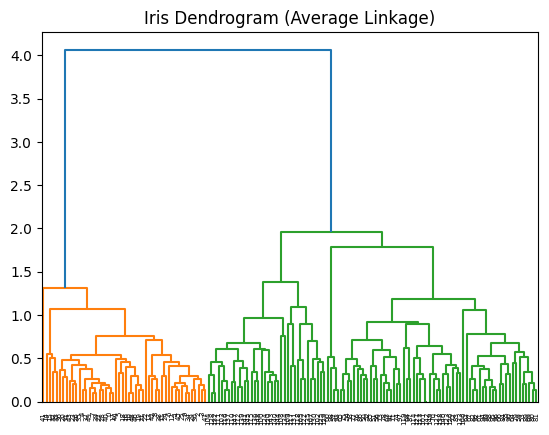

In [15]:
#30. Load the Iris dataset and use hierarchical clustering to group data. Plot a dendrogram with average linkage.
from scipy.cluster.hierarchy import dendrogram, linkage

iris = load_iris()
linked = linkage(iris.data, 'average')
dendrogram(linked)
plt.title("Iris Dendrogram (Average Linkage)")
plt.show()

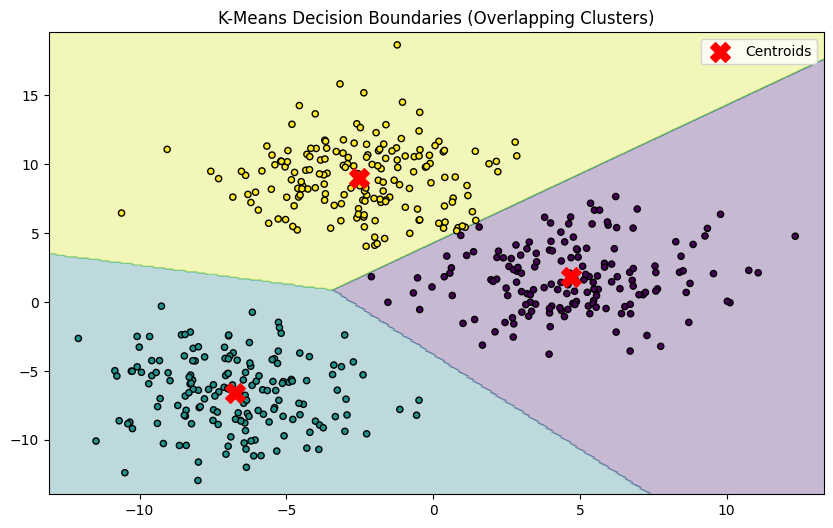

In [16]:
#31. Generate synthetic data with overlapping clusters using make_blobs, then apply K-Means and visualize with decision boundaries.
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

# 1. Generate synthetic data with overlapping clusters (higher cluster_std = more overlap)
X, y = make_blobs(n_samples=500, centers=3, cluster_std=2.5, random_state=42)

# 2. Apply K-Means
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X)

# 3. Create a mesh grid to plot the decision boundaries
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

# 4. Predict across the entire mesh grid
Z = kmeans.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 5. Plotting
plt.figure(figsize=(10, 6))
# Plot the decision regions
plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
# Plot the data points
plt.scatter(X[:, 0], X[:, 1], c=kmeans.labels_, s=20, edgecolor='k', cmap='viridis')
# Plot the centroids
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=200, marker='X', c='red', label='Centroids')

plt.title("K-Means Decision Boundaries (Overlapping Clusters)")
plt.legend()
plt.show()

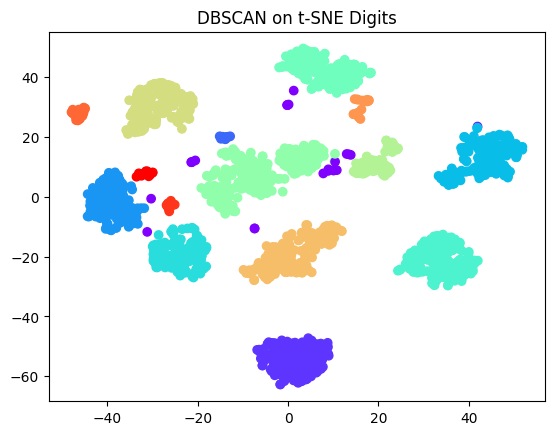

In [17]:
#32. Load the Digits dataset and apply DBSCAN after reducing dimensions with t-SNE. Visualize the results.
from sklearn.manifold import TSNE

X_tsne = TSNE(n_components=2).fit_transform(digits.data)
dbscan = DBSCAN(eps=3, min_samples=10) # Parameters vary based on t-SNE scale
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=dbscan.fit_predict(X_tsne), cmap='rainbow')
plt.title("DBSCAN on t-SNE Digits")
plt.show()

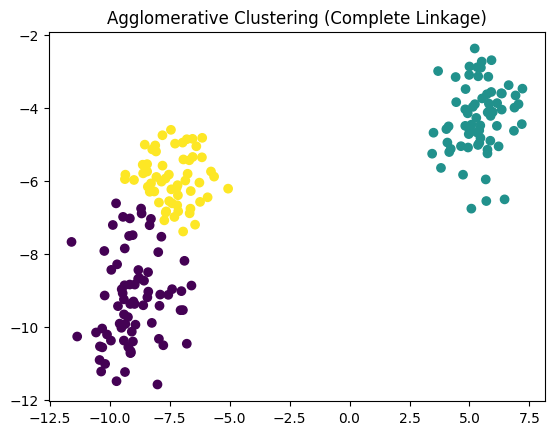

In [18]:
#33. Generate synthetic data using make_blobs and apply Agglomerative Clustering with complete linkage. Plot the result.
X, _ = make_blobs(n_samples=200, centers=3)
agg = AgglomerativeClustering(n_clusters=3, linkage='complete')
plt.scatter(X[:, 0], X[:, 1], c=agg.fit_predict(X))
plt.title("Agglomerative Clustering (Complete Linkage)")
plt.show()

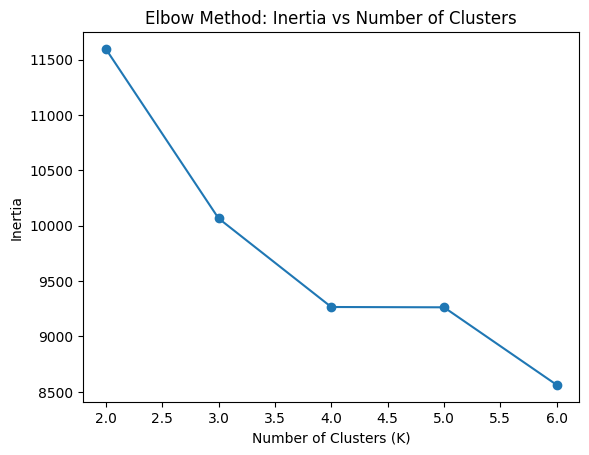

In [19]:
#34. Load the Breast Cancer dataset and compare inertia values for K = 2 to 6 using K-Means. Show results in a line plot.
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

data = load_breast_cancer()
X = StandardScaler().fit_transform(data.data)
inertia = []
K_range = range(2, 7)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42).fit(X)
    inertia.append(kmeans.inertia_)

plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method: Inertia vs Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.show()

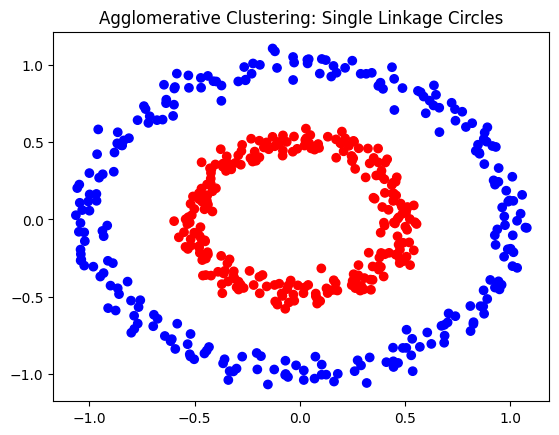

In [20]:
#35. Generate synthetic concentric circles using make_circles and cluster using Agglomerative Clustering with single linkage.
from sklearn.datasets import make_circles
from sklearn.cluster import AgglomerativeClustering

X, _ = make_circles(n_samples=500, factor=0.5, noise=0.05)
# 'single' linkage is key for non-spherical shapes
agg = AgglomerativeClustering(n_clusters=2, linkage='single')
plt.scatter(X[:, 0], X[:, 1], c=agg.fit_predict(X), cmap='bwr')
plt.title("Agglomerative Clustering: Single Linkage Circles")
plt.show()

In [21]:
#36. Use the Wine dataset, apply DBSCAN after scaling the data, and count the number of clusters (excluding noise).
from sklearn.datasets import load_wine
from sklearn.cluster import DBSCAN
import numpy as np

wine = load_wine()
X = StandardScaler().fit_transform(wine.data)
dbscan = DBSCAN(eps=2.5, min_samples=5).fit(X)

# Labels of -1 represent noise. We use set() to find unique labels.
labels = dbscan.labels_
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print(f"Number of clusters (excluding noise): {n_clusters}")

Number of clusters (excluding noise): 1


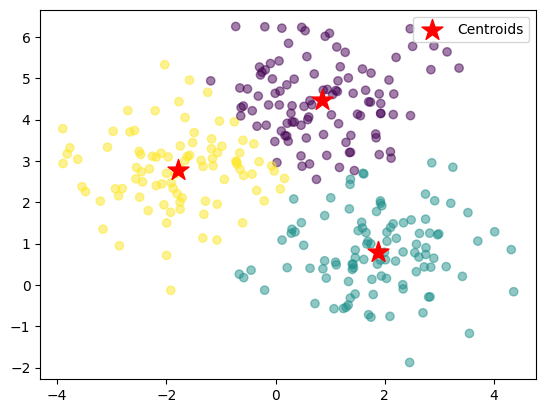

In [22]:
#37. Generate synthetic data with make_blobs and apply KMeans. Then plot the cluster centers on top of the data points.
X, _ = make_blobs(n_samples=300, centers=3, random_state=0)
kmeans = KMeans(n_clusters=3).fit(X)

plt.scatter(X[:, 0], X[:, 1], c=kmeans.labels_, alpha=0.5)
# Plotting the centroids as large red markers
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=250, c='red', marker='*', label='Centroids')
plt.legend()
plt.show()

In [23]:
#38. Load the Iris dataset, cluster with DBSCAN, and print how many samples were identified as noise.
from sklearn.datasets import load_iris

iris = load_iris()
X = StandardScaler().fit_transform(iris.data)
dbscan = DBSCAN(eps=0.5, min_samples=5).fit(X)

noise_count = list(dbscan.labels_).count(-1)
print(f"Number of noise samples: {noise_count}")

Number of noise samples: 34


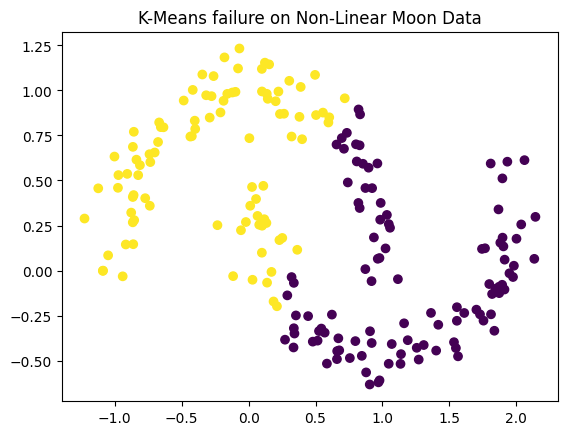

In [24]:
#39. Generate synthetic non-linearly separable data using make_moons, apply K-Means, and visualize the clustering result.
from sklearn.datasets import make_moons

X, _ = make_moons(n_samples=200, noise=0.1, random_state=42)
kmeans = KMeans(n_clusters=2).fit(X)

plt.scatter(X[:, 0], X[:, 1], c=kmeans.labels_, cmap='viridis')
plt.title("K-Means failure on Non-Linear Moon Data")
plt.show()

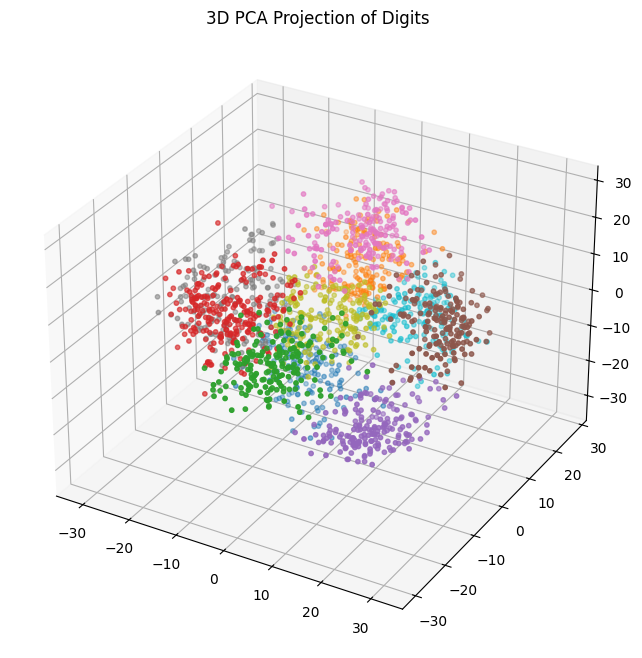

In [26]:
#40. Load the Digits dataset, apply PCA to reduce to 3 components, then use KMeans and visualize with a 3D scatter plot.
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

digits = load_digits()
pca = PCA(n_components=3)
X_3D = pca.fit_transform(digits.data)

kmeans = KMeans(n_clusters=10, random_state=0).fit(X_3D)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_3D[:, 0], X_3D[:, 1], X_3D[:, 2], c=kmeans.labels_, cmap='tab10', s=10)
ax.set_title("3D PCA Projection of Digits")
plt.show()

In [27]:
#41. Generate synthetic blobs with 5 centers and apply KMeans. Then use silhouette_score to evaluate the clustering.
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X, _ = make_blobs(n_samples=500, centers=5, random_state=42)
kmeans = KMeans(n_clusters=5, random_state=42).fit(X)
score = silhouette_score(X, kmeans.labels_)

print(f"Silhouette Score for 5 clusters: {score:.4f}")

Silhouette Score for 5 clusters: 0.6787


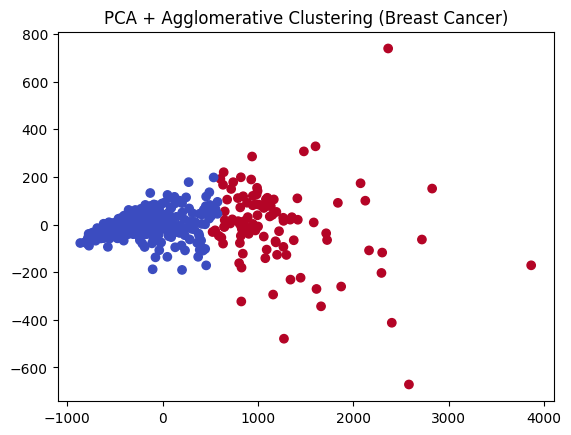

In [28]:
#42. Load the Breast Cancer dataset, reduce dimensionality using PCA, and apply Agglomerative Clustering. Visualize in 2D.
from sklearn.datasets import load_breast_cancer
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

data = load_breast_cancer()
X_pca = PCA(n_components=2).fit_transform(data.data)
agg = AgglomerativeClustering(n_clusters=2).fit_predict(X_pca)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=agg, cmap='coolwarm')
plt.title("PCA + Agglomerative Clustering (Breast Cancer)")
plt.show()

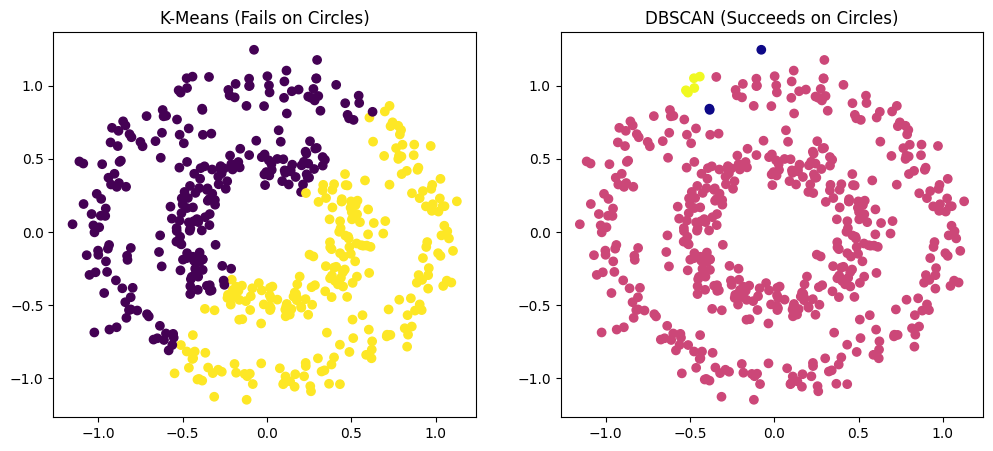

In [29]:
#43. Generate noisy circular data using make_circles and visualize clustering results from KMeans and DBSCAN side-by-side.
from sklearn.datasets import make_circles
from sklearn.cluster import DBSCAN

X, _ = make_circles(n_samples=500, factor=0.5, noise=0.08, random_state=42)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# KMeans
km_labels = KMeans(n_clusters=2).fit_predict(X)
ax1.scatter(X[:, 0], X[:, 1], c=km_labels, cmap='viridis')
ax1.set_title("K-Means (Fails on Circles)")

# DBSCAN
db_labels = DBSCAN(eps=0.15, min_samples=5).fit_predict(X)
ax2.scatter(X[:, 0], X[:, 1], c=db_labels, cmap='plasma')
ax2.set_title("DBSCAN (Succeeds on Circles)")
plt.show()

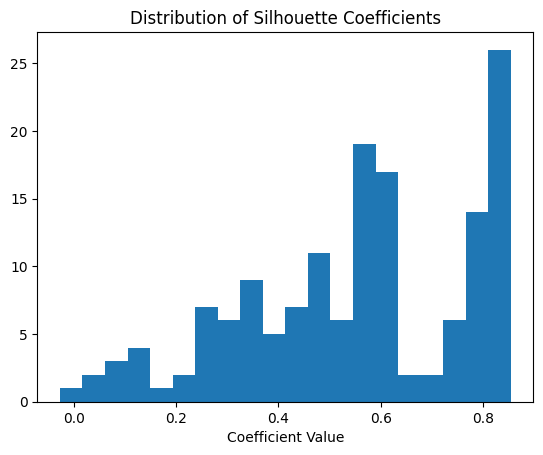

In [30]:
#44. Load the Iris dataset and plot the Silhouette Coefficient for each sample after KMeans clustering.
from sklearn.metrics import silhouette_samples
import numpy as np

iris = load_iris()
kmeans = KMeans(n_clusters=3, random_state=42).fit(iris.data)
sample_silhouette_values = silhouette_samples(iris.data, kmeans.labels_)

plt.hist(sample_silhouette_values, bins=20)
plt.title("Distribution of Silhouette Coefficients")
plt.xlabel("Coefficient Value")
plt.show()

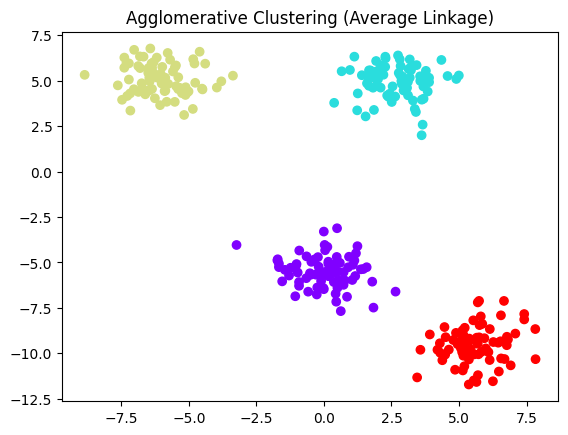

In [31]:
#45. Generate synthetic data using make_blobs and apply Agglomerative Clustering with 'average' linkage. Visualize clusters.
X, _ = make_blobs(n_samples=300, centers=4, random_state=10)
agg = AgglomerativeClustering(n_clusters=4, linkage='average')
plt.scatter(X[:, 0], X[:, 1], c=agg.fit_predict(X), cmap='rainbow')
plt.title("Agglomerative Clustering (Average Linkage)")
plt.show()

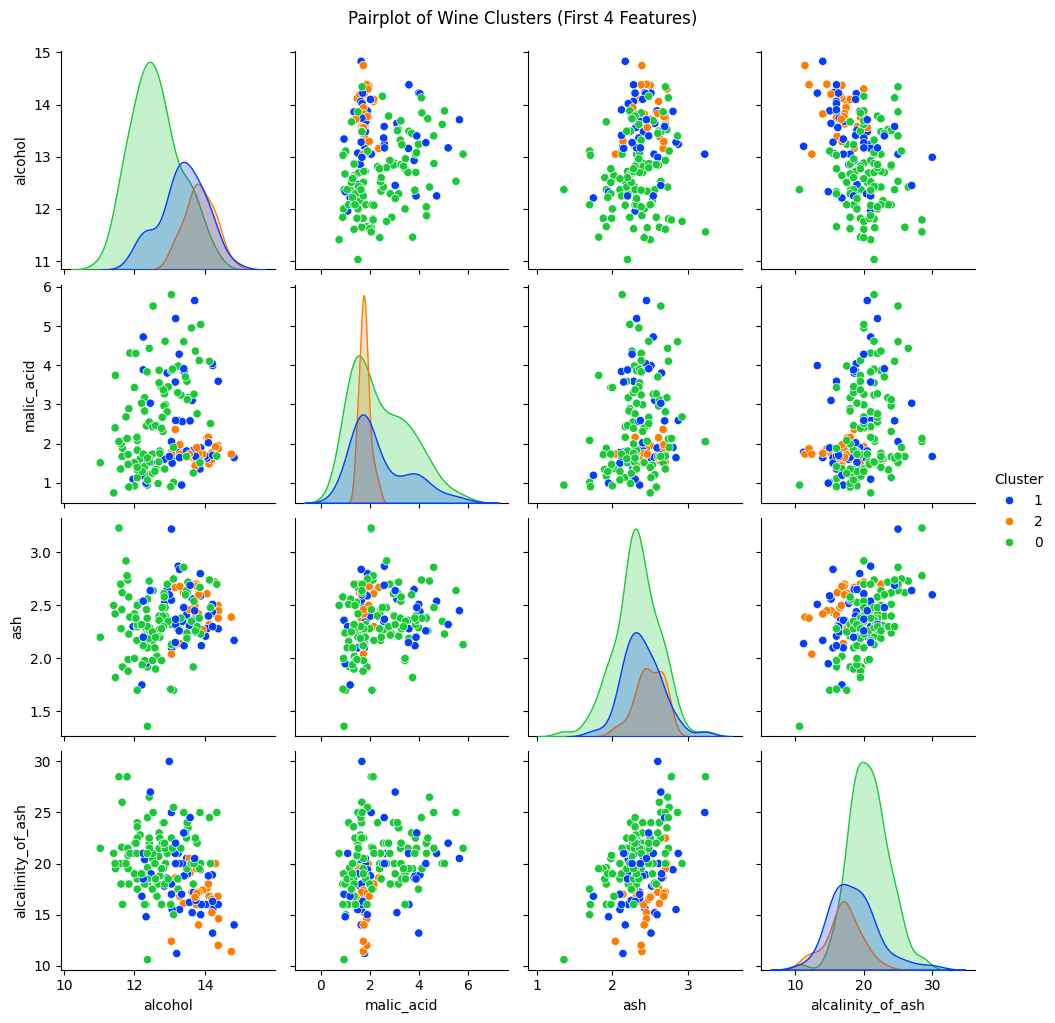

In [32]:
#46. Load the Wine dataset, apply KMeans, and visualize the cluster assignments in a seaborn pairplot (first 4 features).
import seaborn as sns
import pandas as pd
from sklearn.datasets import load_wine

wine = load_wine()
kmeans = KMeans(n_clusters=3, random_state=42).fit(wine.data)

df = pd.DataFrame(wine.data[:, :4], columns=wine.feature_names[:4])
df['Cluster'] = kmeans.labels_.astype(str)

sns.pairplot(df, hue='Cluster', palette='bright')
plt.suptitle("Pairplot of Wine Clusters (First 4 Features)", y=1.02)
plt.show()

In [33]:
#47. Generate noisy blobs using make_blobs and use DBSCAN to identify both clusters and noise points. Print the count.
X, _ = make_blobs(n_samples=400, centers=3, cluster_std=1.0, random_state=42)
# Adding manual noise
noise = np.random.uniform(low=-10, high=10, size=(20, 2))
X = np.vstack([X, noise])

db = DBSCAN(eps=1.0, min_samples=5).fit(X)
labels = db.labels_

n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print(f"Estimated number of clusters: {n_clusters_}")
print(f"Estimated number of noise points: {n_noise_}")

Estimated number of clusters: 3
Estimated number of noise points: 22


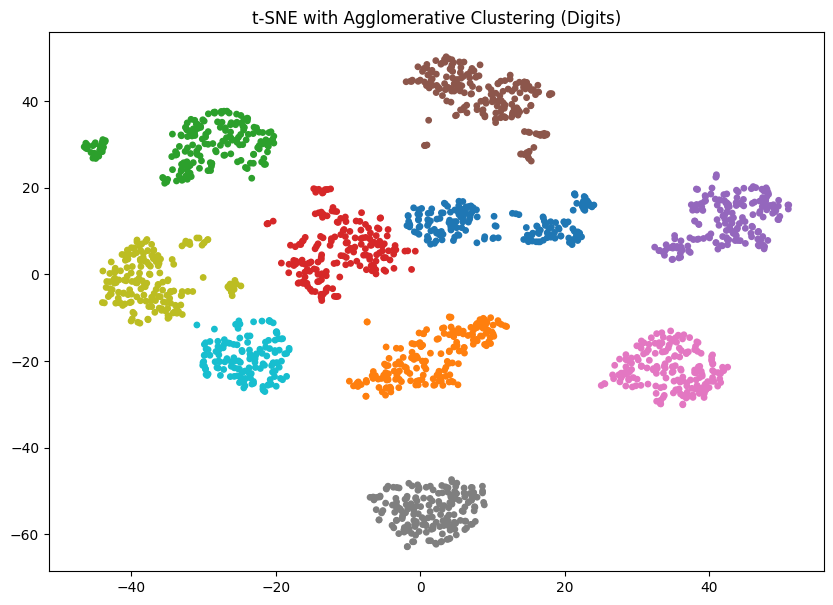

In [34]:
#48. Load the Digits dataset, reduce dimensions using t-SNE, then apply Agglomerative Clustering and plot the clusters.
from sklearn.manifold import TSNE
from sklearn.datasets import load_digits

digits = load_digits()
X_tsne = TSNE(n_components=2, random_state=42).fit_transform(digits.data)
agg_labels = AgglomerativeClustering(n_clusters=10).fit_predict(X_tsne)

plt.figure(figsize=(10, 7))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=agg_labels, cmap='tab10', s=15)
plt.title("t-SNE with Agglomerative Clustering (Digits)")
plt.show()